In [17]:
import jax
import jax.numpy as jnp
import flax.linen as nn
import netket as nk
import optax
from flax.core import freeze, unfreeze
import numpy as np
import netket as nk

from netket.graph.common_lattices import Chain
from netket.operator.fermion import destroy as c
from netket.operator.fermion import create as cdag
from netket.operator.fermion import number as nc

print('NetKet version:', nk.__version__)
print("=" * 80)
print(">>> [VMC 终极平滑流水线] Stage 1 (官方 Slater) -> Stage 2 (稠密 AGP+Jastrow) -> Stage 3 (Neural Jastrow)")
print("=" * 80)

# ======================================================================
# 阶段一：官方 Slater 决定式 (无阻力高速收敛)
# ======================================================================
# 直接复用官方，不需要我们自己写模型类，稍后在执行区直接实例化
class LogSlaterDeterminant(nn.Module):
    hilbert: nk.hilbert.SpinOrbitalFermions

    @nn.compact
    def __call__(self, n):
        # 直接复用 NetKet 内建 Slater2nd（限制在固定粒子数子空间）
        return nk.models.Slater2nd(
            self.hilbert, generalized=False, restricted=True, param_dtype=float
        )(n)
# ======================================================================
# 阶段二 & 三通用的 AGP 核心模块 (Factorized Redundancy 版)
# ======================================================================
class SmoothAGPJastrow(nn.Module):
    hilbert: nk.hilbert.SpinOrbitalFermions
    n_sites: int
    n_up: int
    n_down: int

    @nn.compact
    def __call__(self, n):
        dtype = jnp.float64
        x = n.astype(dtype)
        
        # 1. 声明极度冗余的稠密矩阵 A (N x N)
        A = self.param('A', nn.initializers.normal(stddev=0.01), (self.n_sites, self.n_sites), dtype)
        
        # 2. 构造固定的物理符号矩阵 (Signature Matrix)
        # 前 n_up 个为 1 (占据态)，后 n_sites - n_up 个为 -1 (虚态)
        sig = jnp.concatenate([jnp.ones(self.n_up), -jnp.ones(self.n_sites - self.n_up)])
        
        # 3. 【核心冗余映射】：F = A * Sigma * A^T
        # 纯粹的矩阵乘法，绝对平滑，无 tanh 饱和，无 expm 扭曲！
        F_matrix = jnp.dot(A * sig, A.T)
        
        up_occ = x[..., :self.n_sites]
        down_occ = x[..., self.n_sites:]
        
        def get_occupied_indices(occ_array, num_particles):
            return jnp.argsort(-occ_array, axis=-1)[..., :num_particles]
        idx_up = get_occupied_indices(up_occ, self.n_up)
        idx_down = get_occupied_indices(down_occ, self.n_down)
        
        def extract_submatrix(idx_u, idx_d):
            return F_matrix[idx_u[:, None], idx_d]
        sub_F = jax.vmap(extract_submatrix)(idx_up, idx_down) if x.ndim > 1 else extract_submatrix(idx_up, idx_down)
            
        sign, log_det = jnp.linalg.slogdet(sub_F)
        log_agp = log_det + jnp.log(sign.astype(jnp.complex128))
        
        # 杂质双占惩罚
        g = self.param('impurity_penalty', nn.initializers.constant(5.0), ())
        is_double_occupied = n[..., 0] * n[..., self.n_sites]
        log_jastrow = -g * is_double_occupied.astype(dtype)
        
        return log_agp + log_jastrow
    # ======================================================================
# 阶段三：防爆版 AGP + 单层 Neural Jastrow
# ======================================================================
class SmoothAGPNeuralJastrow(nn.Module):
    hilbert: nk.hilbert.SpinOrbitalFermions
    n_sites: int
    n_up: int
    n_down: int
    hidden_dims: tuple = (16,) 

    @nn.compact
    def __call__(self, n):
        dtype = jnp.float64
        x = n.astype(dtype)
        
        # 1. 声明极度冗余的稠密矩阵 A (N x N)
        A = self.param('A', nn.initializers.normal(stddev=0.01), (self.n_sites, self.n_sites), dtype)
        
        # 2. 构造固定的物理符号矩阵 (Signature Matrix)
        # 前 n_up 个为 1 (占据态)，后 n_sites - n_up 个为 -1 (虚态)
        sig = jnp.concatenate([jnp.ones(self.n_up), -jnp.ones(self.n_sites - self.n_up)])
        
        # 3. 【核心冗余映射】：F = A * Sigma * A^T
        # 纯粹的矩阵乘法，绝对平滑，无 tanh 饱和，无 expm 扭曲！
        F_matrix = jnp.dot(A * sig, A.T)
        
        up_occ = x[..., :self.n_sites]
        down_occ = x[..., self.n_sites:]
        
        def get_occupied_indices(occ_array, num_particles):
            return jnp.argsort(-occ_array, axis=-1)[..., :num_particles]
        idx_up = get_occupied_indices(up_occ, self.n_up)
        idx_down = get_occupied_indices(down_occ, self.n_down)
        
        def extract_submatrix(idx_u, idx_d):
            return F_matrix[idx_u[:, None], idx_d]
        sub_F = jax.vmap(extract_submatrix)(idx_up, idx_down) if x.ndim > 1 else extract_submatrix(idx_up, idx_down)
            
        sign, log_det = jnp.linalg.slogdet(sub_F)
        log_agp = log_det + jnp.log(sign.astype(jnp.complex128))
        # 杂质双占惩罚
        g = self.param('impurity_penalty', nn.initializers.constant(5.0), ())
        is_double_occupied = n[..., 0] * n[..., self.n_sites]
        # --- 2. Neural Jastrow ---
        y = x
        for dim in self.hidden_dims:
            y = nn.Dense(features=dim, dtype=dtype)(y)
            y = nn.gelu(y) 
            
        log_neural_jastrow = nn.Dense(features=1, dtype=dtype)(y)
        log_neural_jastrow = jnp.squeeze(log_neural_jastrow, axis=-1)-g * is_double_occupied.astype(dtype)
        
        return log_agp + log_neural_jastrow

# (Stage 3 的 Neural Jastrow 版本只需在末尾加上 MLP，前面 AGP 构建方式与上面完全一致)

NetKet version: 3.21.1.dev13+gbf43effcb
>>> [VMC 终极平滑流水线] Stage 1 (官方 Slater) -> Stage 2 (稠密 AGP+Jastrow) -> Stage 3 (Neural Jastrow)


chain nodes = 11 , chain edges = 10
n_orbitals = 12
fixed particles (N_up, N_dn) = (6, 6)


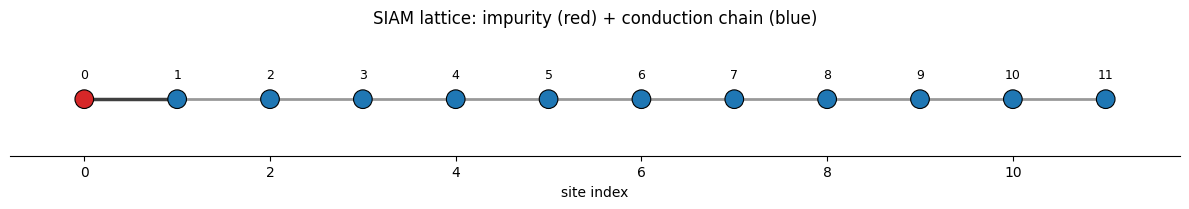

reference E_gs = Not Available (System too large for ED)
sampler graph nodes/edges = 12 11
seeds: (11, 101, 22, 202, 33, 303)


In [2]:
L = 11  # 导带链长度（不含杂质）
chain = Chain(L, pbc=False)
N = chain.n_nodes   # 格点数量，后续会被应用为神经网络的优化参数数量

impurity_site = 0
conduction_offset = 1  # 导带链局部索引 i -> 全局站点 i+1
n_orbitals = L + 1  # 1 个杂质轨道 + L 个导带轨道

if n_orbitals % 2 != 0:
    raise ValueError("n_orbitals 必须为偶数，才能设置 N_up = N_dn = n_orbitals/2")

N_up = n_orbitals // 2
N_dn = n_orbitals // 2

# 在这里直接限制 Hilbert 空间粒子数
hi = nk.hilbert.SpinOrbitalFermions(
    n_orbitals, s=1 / 2, n_fermions_per_spin=(N_up, N_dn)
 )

print('chain nodes =', chain.n_nodes, ', chain edges =', chain.n_edges)
print('n_orbitals =', n_orbitals)
print('fixed particles (N_up, N_dn) =', (N_up, N_dn))


U = 4.0
V = 0.15
ti = np.ones(L - 1)  # t_i: 导带链上相邻站点之间的 hopping, 长度 L-1

H = 0.0

# 杂质上的库仑相互作用: U (n_d↑ - 1/2)(n_d↓ - 1/2)
n_d_up = nc(hi, impurity_site, sz=+1)
n_d_dn = nc(hi, impurity_site, sz=-1)
H += U * (n_d_up - 0.5) @ (n_d_dn - 0.5)

h_pin = 0.00
H -= h_pin * 0.5 * (n_d_up - n_d_dn)
# 杂质-导带首站点混成: V Σσ (d†σ c0σ + c0†σ dσ)
c0_site = conduction_offset
for sz in (+1, -1):
    H += V * (cdag(hi, impurity_site, sz=sz) @ c(hi, c0_site, sz=sz))
    H += V * (cdag(hi, c0_site, sz=sz) @ c(hi, impurity_site, sz=sz))

# 导带链 hopping: Σσ Σ_i t_i (c†_{iσ} c_{i-1,σ} + h.c.)
# 使用 Chain(L) 的边来确定一维最近邻，局部索引 (0..L-1) 需要偏移到全局站点 (1..L)。
for i_local, j_local in chain.edges():
    left_local, right_local = sorted((i_local, j_local))
    t_bond = ti[left_local]

    left_site = left_local + conduction_offset
    right_site = right_local + conduction_offset

    for sz in (+1, -1):
        H += t_bond * (cdag(hi, right_site, sz=sz) @ c(hi, left_site, sz=sz))
        H += t_bond * (cdag(hi, left_site, sz=sz) @ c(hi, right_site, sz=sz))

H
from matplotlib import pyplot as plt

fig, ax = plt.subplots(figsize=(12, 2.2))

# 导带内部边（将 chain 的局部索引映射到全局站点 1..L）
for i_local, j_local in chain.edges():
    ax.plot(
        [i_local + conduction_offset, j_local + conduction_offset],
        [0, 0],
        color="0.6",
        lw=2,
        zorder=1,
    )

# 杂质-导带首站点混成边
ax.plot([impurity_site, c0_site], [0, 0], color="0.25", lw=2.5, zorder=2)

# 节点着色：杂质红色，其它导带蓝色
x = np.arange(n_orbitals)
y = np.zeros(n_orbitals)
node_colors = ["tab:red"] + ["tab:blue"] * L
ax.scatter(x, y, c=node_colors, s=180, edgecolors="black", linewidths=0.8, zorder=3)

for site in range(n_orbitals):
    ax.text(site, 0.08, str(site), ha="center", va="bottom", fontsize=9)

ax.set_yticks([])
ax.set_xlabel("site index")
ax.set_title("SIAM lattice: impurity (red) + conduction chain (blue)")
ax.set_xlim(-0.8, n_orbitals - 0.2)
ax.set_ylim(-0.25, 0.3)
ax.spines["left"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["top"].set_visible(False)
plt.tight_layout()
plt.show()
import jax
import jax.numpy as jnp
import flax.linen as nn
import netket as nk
from functools import partial

# ========= Reproducibility seeds =========
SEED_MODEL_SLATER = 11
SEED_SAMPLER_SLATER = 101
SEED_MODEL_NJ = 22
SEED_SAMPLER_NJ = 202
SEED_MODEL_BF = 33
SEED_SAMPLER_BF = 303

# 给采样器构造“空间轨道图”：杂质-首导带 + 导带链最近邻
sampler_edges = [(impurity_site, c0_site)]
sampler_edges += [
    (min(i, j) + conduction_offset, max(i, j) + conduction_offset)
    for (i, j) in chain.edges()
 ]
graph_sampler = nk.graph.Graph(edges=sampler_edges, n_nodes=n_orbitals)

# ==============================================================================
# 体系太大，已彻底移除 ED (Exact Diagonalization) 精确求解部分
# ==============================================================================
E_gs = None 

print("reference E_gs = Not Available (System too large for ED)")
print("sampler graph nodes/edges =", graph_sampler.n_nodes, graph_sampler.n_edges)
print(
    "seeds:",
    (SEED_MODEL_SLATER, SEED_SAMPLER_SLATER, SEED_MODEL_NJ, SEED_SAMPLER_NJ, SEED_MODEL_BF, SEED_SAMPLER_BF),
)

In [14]:
import jax.scipy.sparse.linalg as jsp_linalg

# ======================================================================
# 【升级版优化器配置】：专治 AGP 梯度爆炸与 QGT 奇异
# ======================================================================
def get_optimizer_and_sr(steps=200):
    # 1. 稍微降低学习率，防止步伐过大
    lr_schedule = optax.cosine_decay_schedule(init_value=0.01, decay_steps=steps, alpha=0.05)
    
    # 2. 引入更为严格的梯度裁剪 (从 1.0 降到 0.05)
    op = optax.chain(
        optax.clip_by_global_norm(0.05), 
        optax.adam(learning_rate=lr_schedule, b1=0.8, b2=0.999, eps=1e-8)
    )
    
    # 3. 提高 SR 阻尼，并保持底线 (end_value 从 0.001 提高到 0.02)
    sr_shift = optax.linear_schedule(init_value=0.02, end_value=0.02, transition_steps=int(steps*0.8))
    
    # 4. 【核心修复】：直接使用 JAX 原生的 CG 求解器！
    sr = nk.optimizer.SR(
        diag_shift=sr_shift, 
        #solver=jsp_linalg.cg,  # <--- 修复了这里的接口报错
        solver=nk.optimizer.solver.pinv,
        holomorphic=False, 
        qgt=nk.optimizer.qgt.QGTJacobianDense
    )
    return op, sr
# 通用参数定义 (假设外部环境已定义 hi, H, graph_sampler, n_orbitals, N_up, N_dn)
N_ITER = 200
sa = nk.sampler.MetropolisFermionHop(hi, graph=graph_sampler)

In [ ]:
# ======================================================================
# 【抗爆版优化器配置】：抛弃 Adam，回归纯净的自然梯度下降
# ======================================================================
def get_optimizer_and_sr(steps=300):
    # 1. 极其保守的学习率 (SGD 不需要那么大的 learning rate)
    # 使用 0.01 到 0.001 之间的衰减
    lr_schedule = optax.cosine_decay_schedule(init_value=0.01, decay_steps=steps, alpha=0.1)
    
    # 2. 【核心修复】：必须使用纯 SGD！不要用 Adam！
    # 配合极强的梯度裁剪 (global_norm=0.01)，把任何试图穿透节面的异常梯度一刀切掉
    op = optax.chain(
        optax.clip_by_global_norm(0.01), 
        optax.sgd(learning_rate=lr_schedule)  # <-- 救命的改动
    )
    
    # 3. 极其强硬的 SR 摩擦力 (Shift)
    # 永远不要让 diag_shift 降到 0.001 这种危险的边缘，保底 0.01
    sr_shift = optax.linear_schedule(init_value=0.1, end_value=0.01, transition_steps=int(steps*0.8))
    
    sr = nk.optimizer.SR(
        diag_shift=sr_shift, 
        solver=jsp_linalg.cg,  # 依然使用安全的共轭梯度
        holomorphic=False, 
        qgt=nk.optimizer.qgt.QGTJacobianDense
    )
    return op, sr

In [8]:
# ======================================================================
# >>> Stage 1: 官方 Slater2nd (极速寻找平均场轨道)
# ======================================================================
print("\n" + "-" * 80)
print(">>> [Stage 1/3] 正在训练 官方 Slater2nd...")
model_1 = nk.models.Slater2nd(hilbert=hi, restricted=True, generalized=False, param_dtype=float)
vs_1 = nk.vqs.MCState(sampler=sa, model=model_1, n_samples=2**12, n_discard_per_chain=32)
op_1, sr_1 = get_optimizer_and_sr(N_ITER)
gs_1 = nk.VMC(hamiltonian=H, optimizer=op_1, preconditioner=sr_1, variational_state=vs_1)
log_1 = nk.logging.RuntimeLog()  # 【修改点 1】：实例化并保存日志对象
gs_1.run(n_iter=N_ITER, out=log_1)
print(f"[Stage 1 完] 官方 RHF 能量: {vs_1.expect(H).mean.real:.6f}")


--------------------------------------------------------------------------------
>>> [Stage 1/3] 正在训练 官方 Slater2nd...


100%|██████████| 200/200 [02:40<00:00,  1.25it/s, Energy=-13.334-0.000j ± 0.021 [σ²=1.0e+00, R̂=1.008]]


[Stage 1 完] 官方 RHF 能量: -13.330455


In [20]:
print("\n" + "-" * 80)
print(">>> [Stage 1/3] 正在训练 官方 Slater2nd...")
model_2 = nk.models.Slater2nd(hilbert=hi, restricted=False, generalized=False, param_dtype=float)
vs_2 = nk.vqs.MCState(sampler=sa, model=model_2, n_samples=2**12, n_discard_per_chain=32)
op_2, sr_2 = get_optimizer_and_sr(N_ITER)
gs_2 = nk.VMC(hamiltonian=H, optimizer=op_2, preconditioner=sr_2, variational_state=vs_2)
gs_2.run(n_iter=N_ITER, out=nk.logging.RuntimeLog())
print(f"[Stage 1 完] 官方 UHF 能量: {vs_2.expect(H).mean.real:.6f}")


--------------------------------------------------------------------------------
>>> [Stage 1/3] 正在训练 官方 Slater2nd...


100%|██████████| 200/200 [03:21<00:00,  1.01s/it, Energy=-14.201680-0.000000j ± 0.000026 [σ²=2.2e-06, R̂=1.003]]


[Stage 1 完] 官方 UHF 能量: -14.201710


In [15]:
model_3 = SmoothAGPJastrow(hilbert=hi, n_sites=n_orbitals, n_up=N_up, n_down=N_dn)
vs_3 = nk.vqs.MCState(sampler=sa, model=model_3, n_samples=2**12, n_discard_per_chain=32)

params_3 = unfreeze(vs_3.parameters) if hasattr(vs_3.parameters, 'unfreeze') else dict(vs_3.parameters)

M_matrix = vs_1.parameters['M'] # Stage 1 收敛的矩阵，形状 (N, N_up)

# 初始化一个空的 N x N 矩阵 A
import numpy as np
A_init = np.zeros((n_orbitals, n_orbitals))

# 【核心】：将 RHF 的占据轨道直接塞进 A 的前 N_up 列！
A_init[:, :N_up] = np.array(M_matrix)

# 【唤醒冗余】：给后面的虚轨道加一点极微小的噪声，打破对称性，让优化器有梯度可走
noise = np.random.normal(0, 0.001, (n_orbitals, n_orbitals - N_up))
A_init[:, N_up:] = noise

params_3['A'] = jnp.array(A_init)
vs_3.parameters = params_3
print(" [+] 成功激活不定因子冗余 (Factorized Redundancy)，RHF 态完美继承！")
op_3, sr_3 = get_optimizer_and_sr(N_ITER)
gs_3 = nk.VMC(hamiltonian=H, optimizer=op_3, preconditioner=sr_3, variational_state=vs_3)
log_3 = nk.logging.RuntimeLog()  # 【修改点 1】：实例化并保存日志对象
gs_3.run(n_iter=N_ITER, out=log_3)
print(f"[Stage 2 完] 稠密正交化 AGP 能量: {vs_3.expect(H).mean.real:.6f}")

 [+] 成功激活不定因子冗余 (Factorized Redundancy)，RHF 态完美继承！


  0%|          | 0/200 [00:00<?, ?it/s]

100%|██████████| 200/200 [02:16<00:00,  1.47it/s, Energy=-14.1862-0.0000j ± 0.0025 [σ²=1.9e-02, R̂=1.004]]   


[Stage 2 完] 稠密正交化 AGP 能量: -14.183531


In [18]:
model_4 = SmoothAGPNeuralJastrow(hilbert=hi, n_sites=n_orbitals, n_up=N_up, n_down=N_dn,hidden_dims = (4,))
vs_4 = nk.vqs.MCState(sampler=sa, model=model_4, n_samples=2**12, n_discard_per_chain=32)

params_4 = unfreeze(vs_4.parameters) if hasattr(vs_4.parameters, 'unfreeze') else dict(vs_4.parameters)

M_matrix = vs_1.parameters['M'] # Stage 1 收敛的矩阵，形状 (N, N_up)

# 初始化一个空的 N x N 矩阵 A
import numpy as np
A_init = np.zeros((n_orbitals, n_orbitals))

# 【核心】：将 RHF 的占据轨道直接塞进 A 的前 N_up 列！
A_init[:, :N_up] = np.array(M_matrix)

# 【唤醒冗余】：给后面的虚轨道加一点极微小的噪声，打破对称性，让优化器有梯度可走
noise = np.random.normal(0, 0.001, (n_orbitals, n_orbitals - N_up))
A_init[:, N_up:] = noise

params_4['A'] = jnp.array(A_init)
vs_4.parameters = params_4
print(" [+] 成功激活不定因子冗余 (Factorized Redundancy)，RHF 态完美继承！")
op_4, sr_4 = get_optimizer_and_sr(N_ITER)
gs_4 = nk.VMC(hamiltonian=H, optimizer=op_4, preconditioner=sr_4, variational_state=vs_4)
log_4 = nk.logging.RuntimeLog()  # 【修改点 1】：实例化并保存日志对象
gs_4.run(n_iter=N_ITER, out=log_4)
print(f"[Stage 3 完] 稠密正交化 AGP+NeuralJastrow 能量: {vs_4.expect(H).mean.real:.6f}")

 [+] 成功激活不定因子冗余 (Factorized Redundancy)，RHF 态完美继承！


100%|██████████| 200/200 [02:48<00:00,  1.19it/s, Energy=-14.2040-0.0000j ± 0.0022 [σ²=1.6e-02, R̂=1.002]]   


[Stage 3 完] 稠密正交化 AGP+NeuralJastrow 能量: -14.203130


In [23]:
from math import comb
from scipy.sparse.linalg import eigsh
from netket.experimental.operator import ParticleNumberAndSpinConservingFermioperator2nd

# 直接复用第 3 段已构造好的 H（其 Hilbert 空间已固定粒子数）
N_up_ed, N_dn_ed = N_up, N_dn
sector_dim = comb(n_orbitals, N_up_ed) * comb(n_orbitals, N_dn_ed)
max_dim_for_sparse_ed = 2000000  # 经验阈值，可按机器内存调整

print("ED sector (N_up, N_dn) =", (N_up_ed, N_dn_ed))
print("Estimated Hilbert dimension =", sector_dim)

if sector_dim > max_dim_for_sparse_ed:
    print(
        "[Skip ED] 该扇区维度过大，不执行 to_sparse()/eigsh 以避免内存溢出。"
    )
    print("建议: 减小粒子数（如 1,1 或 2,2）后再做严格对角化。")
else:
    H_ed = ParticleNumberAndSpinConservingFermioperator2nd.from_fermionoperator2nd(H)
    sp_h = H_ed.to_sparse()
    eig_vals, eig_vecs = eigsh(sp_h, k=4, which="SA")
    eig_vals = np.sort(np.real(eig_vals))

    print("Hilbert dimension in this sector =", sp_h.shape[0])
    print("Exact ground-state energy E0 =", eig_vals[0])
    print("Lowest 4 eigenvalues =", eig_vals)

ED sector (N_up, N_dn) = (6, 6)
Estimated Hilbert dimension = 853776
Hilbert dimension in this sector = 853776
Exact ground-state energy E0 = -14.205504941705273
Lowest 4 eigenvalues = [-14.20550494 -14.19792567 -13.68833242 -13.68813464]


正在绘制能量收敛曲线...


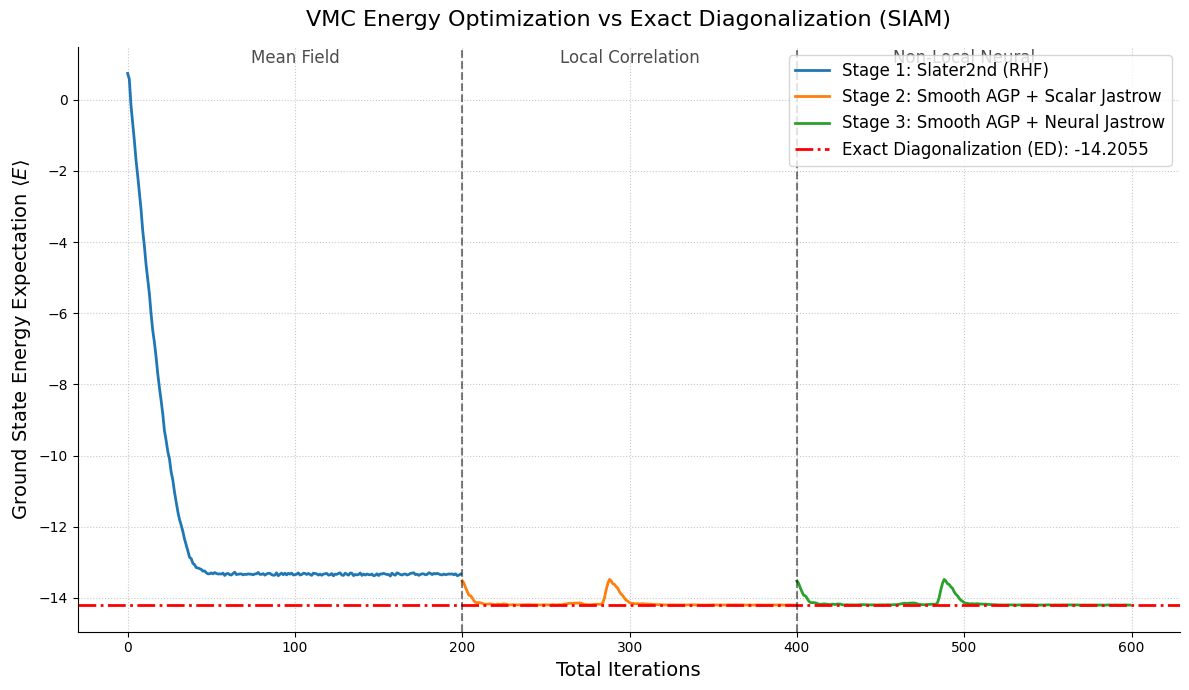


[误差分析]
最终 VMC 能量: -14.186178
严格 ED 能量 : -14.205505
绝对误差 ΔE  : 0.019327
相对误差     : 0.1361%


In [25]:
# ======================================================================
# 【绘图模块】: 三阶段能量下降全景图 (含 ED 基准线)
# ======================================================================
print("正在绘制能量收敛曲线...")

# 极度安全、兼容所有 NetKet 版本的能量提取函数
def extract_energy_and_iters(log_obj):
    hist = log_obj.data["Energy"]
    iters = np.array(hist.iters)
    
    if hasattr(hist, "Mean"):
        energy = np.real(hist.Mean)
    elif hasattr(hist, "mean"):
        energy = np.real(hist.mean)
    elif hasattr(hist, "values"):
        energy = np.array([x.mean.real if hasattr(x, 'mean') else np.real(x) for x in hist.values])
    else:
        energy = np.array([np.real(x) for x in hist])
        
    return iters, energy

# 提取数据
iters_1, energy_1 = extract_energy_and_iters(log_1)
iters_3, energy_4 = extract_energy_and_iters(log_4)
iters_4, energy_4 = extract_energy_and_iters(log_4)

# 步数向后平移
iters_3 = iters_3 + N_ITER
iters_4 = iters_4 + 2 * N_ITER

# 开始画图
plt.figure(figsize=(12, 7))

# 1. 画出 VMC 的三段优化曲线
plt.plot(iters_1, energy_1, label='Stage 1: Slater2nd (RHF)', color='tab:blue', linewidth=2)
plt.plot(iters_3, energy_4, label='Stage 2: Smooth AGP + Scalar Jastrow', color='tab:orange', linewidth=2)
plt.plot(iters_4, energy_4, label='Stage 3: Smooth AGP + Neural Jastrow', color='tab:green', linewidth=2)

# 2. 【核心新增】：画出 ED 的绝对基准线
# 假设你上面的 ED 代码已经成功运行，eig_vals[0] 存在于内存中
E_exact = eig_vals[0] 
plt.axhline(y=E_exact, color='red', linestyle='-.', linewidth=2, label=f'Exact Diagonalization (ED): {E_exact:.4f}')

# 画垂直分割线
plt.axvline(x=N_ITER, color='k', linestyle='--', alpha=0.5)
plt.axvline(x=2*N_ITER, color='k', linestyle='--', alpha=0.5)

# 添加阶段文本标注
plt.text(N_ITER/2, plt.ylim()[1]*0.95, 'Mean Field', horizontalalignment='center', verticalalignment='top', fontsize=12, alpha=0.7)
plt.text(N_ITER + N_ITER/2, plt.ylim()[1]*0.95, 'Local Correlation', horizontalalignment='center', verticalalignment='top', fontsize=12, alpha=0.7)
plt.text(2*N_ITER + N_ITER/2, plt.ylim()[1]*0.95, 'Non-Local Neural', horizontalalignment='center', verticalalignment='top', fontsize=12, alpha=0.7)

# 图表美化
plt.title("VMC Energy Optimization vs Exact Diagonalization (SIAM)", fontsize=16, pad=15)
plt.xlabel("Total Iterations", fontsize=14)
plt.ylabel("Ground State Energy Expectation $\\langle E \\rangle$", fontsize=14)
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend(fontsize=12, loc='upper right')

# 移除上右边框
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# 动态调整 Y 轴下界，给 ED 线留出一点视觉空间
current_ymin, current_ymax = plt.ylim()
if E_exact < current_ymin:
    plt.ylim(E_exact - 0.5, current_ymax)

plt.tight_layout()
plt.show()

# 顺便在控制台打印一下绝对误差
final_vmc_energy = energy_3[-1]
error = final_vmc_energy - E_exact
relative_error = abs(error / E_exact) * 100
print(f"\n[误差分析]")
print(f"最终 VMC 能量: {final_vmc_energy:.6f}")
print(f"严格 ED 能量 : {E_exact:.6f}")
print(f"绝对误差 ΔE  : {error:.6f}")
print(f"相对误差     : {relative_error:.4f}%")

>>> [物理量测量] 正在提取 VMC 态与 ED 基态的物理量...
 [+] 正在计算严格对角化 (ED) 物理量...

模型/阶段                     | 杂质占据 <n>     | 杂质双占 <d>     | 杂质磁矩 <S_z^2>    | 系统 S_z    
------------------------------------------------------------------------------------------
Stage 1: RHF              | 1.010986       | 0.256836       | 0.124329           | 0.0e+00   
Stage 2: UHF              | 0.997803       | 0.000977       | 0.248962           | 0.0e+00   
Stage 3: AGP              | 1.000732       | 0.000732       | 0.249817           | 0.0e+00   
Stage 3: AGP+Jastrow      | 0.996094       | 0.001953       | 0.248047           | 0.0e+00   
Exact Diag (ED)           | 1.000000       | 0.003016       | 0.248492           | 1.4e-16   


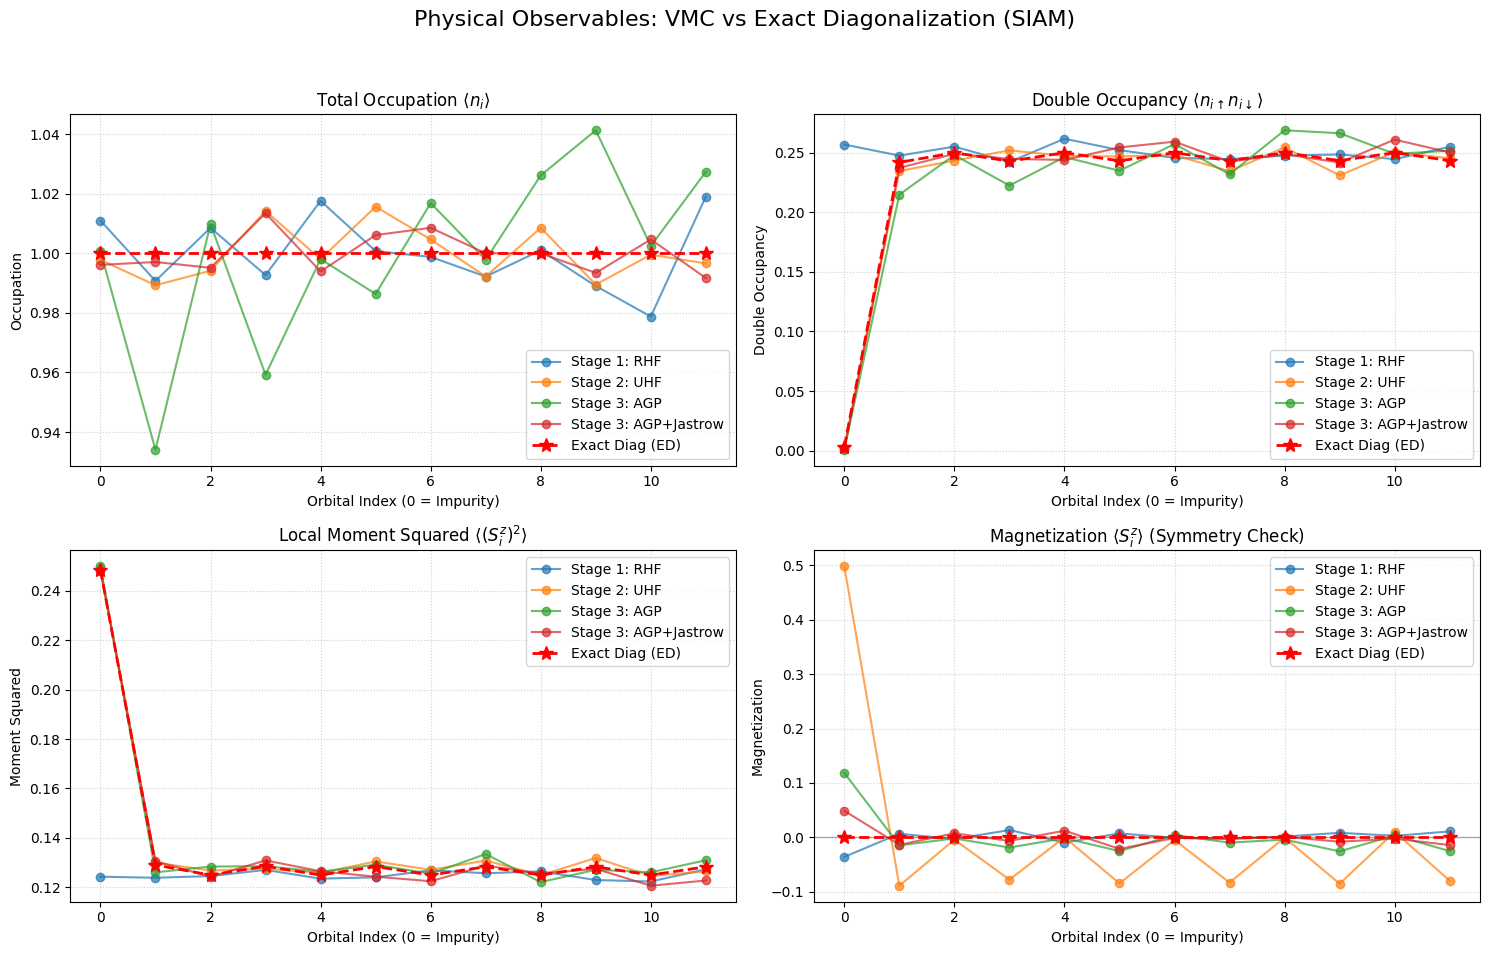

In [27]:
import numpy as np
import matplotlib.pyplot as plt
from netket.operator import FermionOperator2nd

print("=" * 80)
print(">>> [物理量测量] 正在提取 VMC 态与 ED 基态的物理量...")
print("=" * 80)

n_sites = n_orbitals 

# ======================================================================
# 1. 提取 VMC 采样结果
# ======================================================================
vstates = [vs_1, vs_2, vs_3, vs_4] # 如果有 vs_4 请自行加上
stage_names = ['Stage 1: RHF', 'Stage 2: UHF', 'Stage 3: AGP', 'Stage 3: AGP+Jastrow']

def measure_vmc_observables(vs):
    samples = np.asarray(vs.samples)
    samples_flat = samples.reshape(-1, samples.shape[-1])
    n_up_all = samples_flat[:, :n_sites]
    n_dn_all = samples_flat[:, n_sites:]
    
    n_up = np.mean(n_up_all, axis=0)
    n_dn = np.mean(n_dn_all, axis=0)
    n_tot = n_up + n_dn
    S_z = 0.5 * (n_up - n_dn)
    double_occ = np.mean(n_up_all * n_dn_all, axis=0)
    S_z_sq = 0.25 * (n_tot - 2 * double_occ)
    return n_up, n_dn, n_tot, S_z, double_occ, S_z_sq

results = {}
for name, vs in zip(stage_names, vstates):
    results[name] = measure_vmc_observables(vs)

# ======================================================================
# 2. 严格对角化 (ED) 物理量计算
# ======================================================================
print(" [+] 正在计算严格对角化 (ED) 物理量...")
psi0_ed = eig_vecs[:, 0]

ed_n_up = np.zeros(n_sites)
ed_n_dn = np.zeros(n_sites)
ed_double_occ = np.zeros(n_sites)

for i in range(n_sites):
    # 构造标准算符 (假设前 n_sites 是上自旋，后 n_sites 是下自旋)
    op_n_up = FermionOperator2nd(hi, terms={((i, 1), (i, 0)): 1.0})
    op_n_dn = FermionOperator2nd(hi, terms={((i + n_sites, 1), (i + n_sites, 0)): 1.0})
    op_d = FermionOperator2nd(hi, terms={((i, 1), (i, 0), (i + n_sites, 1), (i + n_sites, 0)): 1.0})
    
    # 投影到相同的限制粒子数子空间中
    sp_n_up = ParticleNumberAndSpinConservingFermioperator2nd.from_fermionoperator2nd(op_n_up).to_sparse()
    sp_n_dn = ParticleNumberAndSpinConservingFermioperator2nd.from_fermionoperator2nd(op_n_dn).to_sparse()
    sp_d = ParticleNumberAndSpinConservingFermioperator2nd.from_fermionoperator2nd(op_d).to_sparse()
    
    # 计算期望值 <psi0 | O | psi0>
    ed_n_up[i] = np.real(np.vdot(psi0_ed, sp_n_up.dot(psi0_ed)))
    ed_n_dn[i] = np.real(np.vdot(psi0_ed, sp_n_dn.dot(psi0_ed)))
    ed_double_occ[i] = np.real(np.vdot(psi0_ed, sp_d.dot(psi0_ed)))

ed_n_tot = ed_n_up + ed_n_dn
ed_S_z = 0.5 * (ed_n_up - ed_n_dn)
ed_S_z_sq = 0.25 * (ed_n_tot - 2 * ed_double_occ)

results['Exact Diag (ED)'] = (ed_n_up, ed_n_dn, ed_n_tot, ed_S_z, ed_double_occ, ed_S_z_sq)
# 把 ED 加入绘图列表
all_names = stage_names + ['Exact Diag (ED)']

# ======================================================================
# 3. 控制台输出 (重点对比杂质位)
# ======================================================================
print("\n" + "=" * 90)
print(f"{'模型/阶段':<25} | {'杂质占据 <n>':<12} | {'杂质双占 <d>':<12} | {'杂质磁矩 <S_z^2>':<15} | {'系统 S_z':<10}")
print("-" * 90)

for name in all_names:
    n_up, n_dn, n_tot, S_z, double_occ, S_z_sq = results[name]
    print(f"{name:<25} | {n_tot[0]:<14.6f} | {double_occ[0]:<14.6f} | {S_z_sq[0]:<18.6f} | {np.sum(S_z):<10.1e}")

# ======================================================================
# 4. 终极绘图：VMC vs ED
# ======================================================================
sites = np.arange(n_sites)
fig, axs = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle("Physical Observables: VMC vs Exact Diagonalization (SIAM)", fontsize=16)

# 我们为 ED 专门分配红色和独特的虚线标记
def plot_obs(ax, obs_index, title, ylabel):
    for name in all_names:
        obs_data = results[name][obs_index]
        if "ED" in name:
            ax.plot(sites, obs_data, color='red', marker='*', markersize=10, linestyle='--', linewidth=2, label=name, zorder=10)
        else:
            ax.plot(sites, obs_data, marker='o', alpha=0.7, label=name)
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.set_xlabel("Orbital Index (0 = Impurity)")
    ax.grid(True, linestyle=':', alpha=0.6)
    ax.legend()

# 图 1：总占据数分布 (索引 2)
plot_obs(axs[0, 0], 2, "Total Occupation $\\langle n_i \\rangle$", "Occupation")

# 图 2：局域双占据 (索引 4)
plot_obs(axs[0, 1], 4, "Double Occupancy $\\langle n_{i\\uparrow} n_{i\\downarrow} \\rangle$", "Double Occupancy")

# 图 3：局域磁矩平方 (索引 5)
plot_obs(axs[1, 0], 5, "Local Moment Squared $\\langle (S_i^z)^2 \\rangle$", "Moment Squared")

# 图 4：Z方向磁矩 (索引 3)
plot_obs(axs[1, 1], 3, "Magnetization $\\langle S_i^z \\rangle$ (Symmetry Check)", "Magnetization")
axs[1, 1].axhline(0, color='black', linestyle='-', linewidth=1, alpha=0.3)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()